# Notebook for comparing our impementation of Decision tree and Random Forest against SKlearn and Gradient Boosting

## Imports

In [34]:
from src_gregor.regression_tree import DecisionTreeRegressor as TreeCustom
from src_gregor.random_forest import RandomForestRegressor as RFCustom

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import os

# sklearn models, metrics and helpers
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error, median_absolute_error

# typing
from typing import Dict, Tuple, List, Any

## Main performance comparison

In [ ]:
def split_df(df: pd.DataFrame, 
             target_name: str, 
             test_size: float = 0.2, 
             random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    '''
    Helpfer function for splitting the df into X and y and subsequently training and test data
    
    :param df: DataFrame
    :type df: pd.DataFrame
    :param target_name: Target column name
    :type target_name: str
    :param test_size: Define the split size in range 0-1
    :type test_size: float
    :param random_state: random state integer
    :type random_state: int
    :return: X_train, X_test, y_train, y_test
    :rtype: Tuple[DataFrame, DataFrame, Series[Any], Series[Any]]
    '''
    X = df.drop(columns=[target_name])
    y = df[target_name]
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

def evaluate_run(name: str, y_true, y_pred) -> Dict[str, float]:
    '''
    :param name: string name of the model being used
    :param y_true: actual target
    :param y_pred: predicted target 
    :return: dictionary containing standard evaluation metrics from sklearn.metrics
    :rtype: Dict[str, float]
    '''
    return {
        "name": name,
        "r2": r2_score(y_true, y_pred),
        "mse": mean_squared_error(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "mape": mean_absolute_percentage_error(y_true, y_pred),
        "medianAE" : median_absolute_error(y_true, y_pred)
    }

# ---------- Comparison Runner ----------
def run_comparison(df: pd.DataFrame, 
                   target_col: str, 
                   tree_hyperparameters: dict = {"classifier__max_depth": [3, 5, 7]}, 
                   RF_hyperparameters: dict = {"classifier__max_depth": [3, 5, 7]},
                   GBR_hyperparameters: dict = None,
                   scoring_technique_cv: str = "r2",
                   preprocessor: object = None,
                   n_estimators: int = 10,
                   cv_folds: int = 5) -> pd.DataFrame:
    '''
    Running/training and comparing our custom implementation vs sklearns 
    regression tree/forest as well as their GradientBoostingRegressor for an additional regression method 
    
    :param df: DataFrame containing features and the target
    :type df: pd.DataFrame
    :param target_col: target column name
    :type target_col: str
    :param *_hyperparameters: hyperparameters to be passed to the respective model in the gridsearchcv
    :type tree_hyperparameters: dict
    :param scoring_technique_cv: scoring technique for gridsearchcv
    :type scoring_technique_cv: str
    :param preprocessor: sklearn transformer (like standardscaler) or just None
    :type preprocessor: object
    :param n_estimators: Number of trees to be trained for the forests
    :type n_estimators: int
    :return: Dataframe containing regression scores (based on evaluate_run())
    :rtype: DataFrame
    '''
    X_train, X_test, y_train, y_test = split_df(df, target_name=target_col)

    # models for comparison
    models = {
        # Trees
        "TreeCustom": (TreeCustom(), tree_hyperparameters if tree_hyperparameters is not None else {}),
        "SklearnTree": (DecisionTreeRegressor(), tree_hyperparameters if tree_hyperparameters is not None else {}),
        
        # Random Forests, 1/3 for custom to align with sklearns way of sampling
        "RFCustom": (RFCustom(max_features=1/3), RF_hyperparameters),
        "SklearnRF": (RandomForestRegressor(), RF_hyperparameters),

        # Additional Regressor
        "SklearnGB": (GradientBoostingRegressor(), GBR_hyperparameters if GBR_hyperparameters else {})
    }

    # scores from the cv in gridsearchcv
    scoring = {
        "r2": "r2",
        "mse": "neg_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "mape": "neg_mean_absolute_percentage_error",
        "medianAE": "neg_median_absolute_error"
    }

    results = []

    for name, (model, param_grid) in models.items():
        pipeline_steps = []
        if preprocessor is not None:
            pipeline_steps.append(("preprocessor", preprocessor))
        pipeline_steps.append(("classifier", model))

        pipe = Pipeline(pipeline_steps)

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring=scoring,
            refit=scoring_technique_cv, # this is what the hyperparameter will be tuning on
            cv=cv_folds,
            return_train_score=False
        )

        start_train = time.time()
        grid.fit(X_train, y_train)
        end_train = time.time()
        training_time = end_train - start_train

        best_pipe = grid.best_estimator_

        start_pred = time.time()
        y_pred = best_pipe.predict(X_test)
        end_pred = time.time()
        prediction_time = end_pred - start_pred

        res = evaluate_run(name, y_test, y_pred)

        # CV metrics (mean across folds for best params)        
        best_idx = grid.best_index_
        res["cv_r2"] = grid.cv_results_["mean_test_r2"][best_idx]
        res["cv_r2_std"] = grid.cv_results_["std_test_r2"][best_idx]

        # sklearn stores these metrics negative due to "higher is better" methodology (which for r2 is in positive range ofc)
        res["cv_mse"] = -grid.cv_results_["mean_test_mse"][best_idx]
        res["cv_mse_std"] = grid.cv_results_["std_test_mse"][best_idx]   

        res["cv_mae"] = -grid.cv_results_["mean_test_mae"][best_idx]
        res["cv_mae_std"] = grid.cv_results_["std_test_mae"][best_idx]

        res["cv_mape"] = -grid.cv_results_["mean_test_mape"][best_idx]
        res["cv_mape_std"] = grid.cv_results_["std_test_mape"][best_idx]

        res["cv_medianAE"] = -grid.cv_results_["mean_test_medianAE"][best_idx]
        res["cv_medianAE_std"] = grid.cv_results_["std_test_medianAE"][best_idx]


        res["best_params"] = grid.best_params_
        res["preprocessor"] = preprocessor.__class__.__name__ if preprocessor is not None else "None"
        res["training_time_sec"] = training_time
        res["prediction_time_sec"] = prediction_time

        results.append(res)

    return pd.DataFrame(results)

# load the data
df_corn = pd.read_csv("data/corn_data_preprocessed.csv")
df_steel  = pd.read_csv("data/steel_industry_data_preprocessed.csv")
df_wave = pd.read_csv("data/wave_energy_farm_preprocessed.csv")

# set the hyperparameters
#tree_hyperparameters = {"classifier__max_depth": [3, 5, 7, None],
#                       "classifier__min_samples_split": [2, 3, 5, 7],
#                       "classifier__min_samples_leaf": [1, 3, 5, 7]}

RF_hyperparameters = {"classifier__max_depth": [3, 7, None],
                       "classifier__min_samples_split": [2, 8],
                       "classifier__min_samples_leaf": [1, 7],
                       "classifier__n_estimators": [1, 5, 10]}

# set this to None because its not necessary for the hand-in and just takes time right now
tree_hyperparameters = None
GBR_hyperparameters = None
   

# run the comparisons
results_corn = run_comparison(df=df_corn,
                              target_col="Yield",
                              tree_hyperparameters=tree_hyperparameters,
                              RF_hyperparameters=RF_hyperparameters,
                              GBR_hyperparameters=GBR_hyperparameters)
results_steel = run_comparison(df=df_steel,
                               target_col="Usage_kWh",
                               tree_hyperparameters=tree_hyperparameters,
                               RF_hyperparameters=RF_hyperparameters,
                               GBR_hyperparameters=GBR_hyperparameters)
results_wave = run_comparison(df= df_wave, 
                               target_col="Total_Power",
                               tree_hyperparameters=tree_hyperparameters,
                               RF_hyperparameters=RF_hyperparameters,
                               GBR_hyperparameters=GBR_hyperparameters)

# save the results
results_corn.to_csv("results/corn_results2.csv", index=False)
results_steel.to_csv("results/steel_results2.csv", index=False)
results_wave.to_csv("results/wave_results2.csv", index=False)

# et voila, print em'
print(results_corn)
print(results_steel)
print(results_wave)


In [ ]:
results_corn

,name,r2,mse,mae,mape,medianAE,cv_r2,cv_r2_std,cv_mse,cv_mse_std,cv_mae,cv_mae_std,cv_mape,cv_mape_std,cv_medianAE,cv_medianAE_std,best_params,preprocessor,training_time_sec,prediction_time_sec
0,TreeCustom,0.652807,5926.526722,44.411542,0.218470,30.000000,0.806585,0.034723,3577.984919,405.397771,40.760328,2.836704,0.199127,0.016063,31.571429,7.062404,{},None,0.433941,0.000311
1,SklearnTree,0.629263,6328.409091,45.984848,0.224897,30.000000,0.789659,0.043711,3868.388970,535.823274,42.539913,3.610560,0.205379,0.011561,30.500000,7.141428,{},None,0.064025,0.001136
2,RFCustom,0.738974,4455.670645,42.792853,0.212558,31.495238,0.822219,0.030116,3358.366342,834.232236,42.498261,5.229184,0.245635,0.030436,30.433607,2.681902,"{'classifier__max_depth': None, 'classifier__m...",None,30.296733,0.023725
3,SklearnRF,0.733683,4545.977773,38.528615,0.181826,25.327358,0.880781,0.021321,2209.455459,281.756830,35.884835,2.023636,0.184222,0.012627,27.990188,2.469565,"{'classifier__max_depth': 7, 'classifier__min_...",None,3.339921,0.001749
4,SklearnGB,0.740229,4434.236782,37.787168,0.187591,25.751028,0.850259,0.030525,2812.945842,659.466916,40.230953,4.932618,0.221353,0.054001,31.338997,5.739309,{},None,0.548977,0.001604


In [ ]:
results_steel

,name,r2,mse,mae,mape,medianAE,cv_r2,cv_r2_std,cv_mse,cv_mse_std,cv_mae,cv_mae_std,cv_mape,cv_mape_std,cv_medianAE,cv_medianAE_std,best_params,preprocessor,training_time_sec,prediction_time_sec
0,TreeCustom,0.995001,5.682151,1.201027,0.070257,0.430302,0.995315,0.000340,5.225170,0.488284,1.154595,0.047441,4.196332e+11,8.392664e+11,0.390614,2.469721e-02,{},None,12.882682,0.026906
1,SklearnTree,0.997825,2.472537,0.536354,0.017163,0.040000,0.998010,0.000173,2.220621,0.240483,0.553862,0.015941,3.984633e+11,7.969267e+11,0.070000,2.175761e-16,{},None,1.368791,0.003865
2,RFCustom,0.997096,3.300724,0.941804,0.040568,0.216434,0.996393,0.000436,4.018810,0.506238,1.009193,0.068942,4.425439e+11,8.850878e+11,0.218895,2.530540e-02,"{'classifier__max_depth': None, 'classifier__m...",None,464.138668,0.836200
3,SklearnRF,0.998699,1.478795,0.381759,0.012820,0.034000,0.998716,0.000151,1.429811,0.172364,0.405819,0.015879,3.974993e+11,7.949986e+11,0.036500,1.483240e-03,"{'classifier__max_depth': None, 'classifier__m...",None,62.565876,0.020214
4,SklearnGB,0.992670,8.332455,1.761416,0.108572,0.669815,0.992257,0.000462,8.615934,0.405215,1.764789,0.034976,3.976968e+11,7.953936e+11,0.655373,3.328748e-02,{},None,17.452144,0.024396


In [ ]:
results_wave

,name,r2,mse,mae,mape,medianAE,cv_r2,cv_r2_std,cv_mse,cv_mse_std,cv_mae,cv_mae_std,cv_mape,cv_mape_std,cv_medianAE,cv_medianAE_std,best_params,preprocessor,training_time_sec,prediction_time_sec
0,TreeCustom,0.995132,7.174360e+07,5170.277941,0.001332,2.090616e+03,0.995066,0.000254,7.452117e+07,3.554152e+06,5124.869469,99.121402,0.001321,0.000025,1.954157e+03,89.941713,{},NaN,46.505299,0.011702
1,SklearnTree,0.995692,6.348580e+07,2805.940423,0.000724,1.396984e-09,0.995462,0.000284,6.855438e+07,4.327361e+06,2999.511382,97.583222,0.000775,0.000026,9.313226e-10,0.000000,{},NaN,7.074099,0.002510
2,RFCustom,0.995378,6.811308e+07,3093.285172,0.000803,9.313226e-10,0.995139,0.000431,7.344264e+07,6.664438e+06,3305.125073,106.731140,0.000861,0.000029,9.313226e-10,0.000000,"{'classifier__max_depth': None, 'classifier__m...",NaN,1107.389377,1.005078
3,SklearnRF,0.997481,3.712154e+07,2677.775068,0.000691,4.664844e+01,0.997378,0.000150,3.960793e+07,2.348121e+06,2808.255391,82.448168,0.000726,0.000022,7.978763e+01,14.824291,"{'classifier__max_depth': None, 'classifier__m...",NaN,557.585293,0.016702
4,SklearnGB,0.992932,1.041725e+08,7955.461323,0.002037,6.191092e+03,0.992931,0.000198,1.067747e+08,2.361687e+06,8070.967891,99.811059,0.002068,0.000025,6.338437e+03,172.418200,{},NaN,281.826520,0.029430


## Parameter experimenting

--- Starting Sensitivity Analysis for Total_Power ---
Testing variation of: max_depth -> [10, 30, 50]
Testing variation of: n_estimators -> [10, 30, 50]
Testing variation of: max_features -> ['log2', 'sqrt', 0.5, None]
Plot saved to: plots/wave_sensitivity_analysis.png


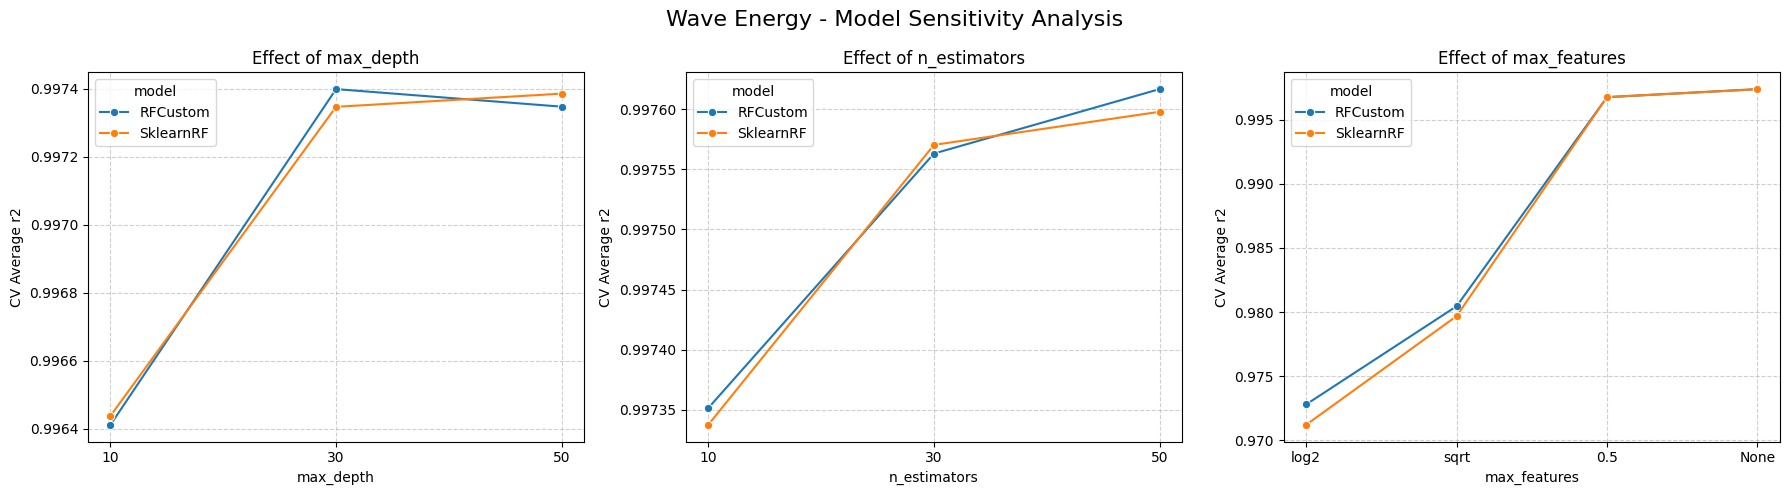

In [ ]:
def plot_sensitivity(results_df: pd.DataFrame, 
                     metric: str = "r2", 
                     title_prefix: str = "", 
                     save_path: str = None):
    """
    Generates line plots for each parameter analyzed and optionally saves the figure.
    
    :param results_df: DataFrame containing the sensitivity analysis results
    :param metric: The metric name used for labeling axes
    :param title_prefix: Title prefix for the plot
    :param save_path: File path (including extension, e.g., 'plots/corn_sensitivity.png') to save the image. 
                      If None, the plot is not saved.
    """
    # Get unique parameters we varied
    varied_params = results_df["param_name"].unique()
    
    # Create a subplot for each parameter
    fig, axes = plt.subplots(1, len(varied_params), figsize=(6 * len(varied_params), 5))
    if len(varied_params) == 1: axes = [axes] # Handle single plot case

    for i, param in enumerate(varied_params):
        ax = axes[i]
        subset = results_df[results_df["param_name"] == param]
        
        # Plotting
        sns.lineplot(data=subset, x="param_value", y="mean_score", hue="model", marker="o", ax=ax)
        
        # Formatting
        ax.set_title(f"Effect of {param}")
        ax.set_ylabel(f"CV Average {metric}")
        ax.set_xlabel(param)
        ax.grid(True, linestyle='--', alpha=0.6)
        
    plt.suptitle(f"{title_prefix} - Model Sensitivity Analysis", fontsize=16)
    plt.tight_layout()
    
    # Save the plot if a path is provided
    if save_path:
        # Create directory if it doesn't exist
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")

    plt.show()

def run_sensitivity_analysis(df: pd.DataFrame, 
                             target_col: str, 
                             base_params: Dict[str, Any],
                             experiments: Dict[str, List[Any]],
                             cv_folds: int = 5) -> pd.DataFrame:
    """
    Runs controlled experiments. In each experiment, it varies ONE parameter 
    from the 'experiments' dict while holding others at 'base_params' values.
    """
    X_train, X_test, y_train, y_test = split_df(df, target_name=target_col)
    
    results = []

    # Models we want to compare in the plots
    model_classes = {
        "RFCustom": RFCustom,
        "SklearnRF": RandomForestRegressor
    }

    print(f"--- Starting Sensitivity Analysis for {target_col} ---")

    for param_name, param_values in experiments.items():
        print(f"Testing variation of: {param_name} -> {param_values}")
        
        for val in param_values:
            for model_name, ModelClass in model_classes.items():
                
                # Merge base params with the current experimental value
                current_params = base_params.copy()
                current_params[param_name] = val
                
                try:
                    model = ModelClass(**current_params)
                except Exception as e:
                    print(f"Skipping {model_name} for {param_name}={val} due to init error: {e}")
                    continue

                # Run Cross Validation
                scores = cross_val_score(model, X_train, y_train, cv=cv_folds, scoring='r2')
                
                results.append({
                    "model": model_name,
                    "param_name": param_name,
                    "param_value": str(val), 
                    "mean_score": scores.mean(),
                    "std_score": scores.std()
                })

    return pd.DataFrame(results)

# Load Data
try:
    df_corn = pd.read_csv("data/corn_data_preprocessed.csv")
    df_steel = pd.read_csv("data/steel_industry_data_preprocessed.csv")
except FileNotFoundError:
    print("Warning: CSV files not found. Please ensure 'data/' directory exists and contains the files.")
    # Creating dummy data for demonstration if files are missing
    df_corn = pd.DataFrame() # ... (add dummy data logic if needed)

if not df_corn.empty and not df_steel.empty and not df_wave.empty:
    # 1. Define the "Control" (Base) Parameters
    base_params = {
        "n_estimators": 10,
        "max_depth": None,      
        "min_samples_split": 2,
        "max_features": None
    }

    # 2. Define the Experiments
    experiments = {
        "max_depth": [3, 5, 10, 30, 50],
        "n_estimators": [5, 10, 30, 50, 70],
        "max_features": ["log2", "sqrt", 0.5, None] 
    }
    
    experiments_wave = {
        "max_depth": [10, 30, 50],
        "n_estimators": [10, 30, 50],
        "max_features": ["log2", "sqrt", 0.5, None] 
    }

    # --- Run for Corn Data ---
    results_corn_sens = run_sensitivity_analysis(
        df=df_corn,
        target_col="Yield",
        base_params=base_params,
        experiments=experiments
    )

    # Plot & Save
    plot_sensitivity(
        results_corn_sens, 
        title_prefix="Corn Yield", 
        save_path="plots/corn_sensitivity_analysis.png"
    )

    # --- Run for Steel Data ---
    results_steel_sens = run_sensitivity_analysis(
        df=df_steel,
        target_col="Usage_kWh",
        base_params=base_params,
        experiments=experiments
    )

    # Plot & Save
    plot_sensitivity(
        results_steel_sens, 
        title_prefix="Steel Industry", 
        save_path="plots/steel_sensitivity_analysis.png"
    )

    # --- Run for Wave Data ---
    results_wave = run_sensitivity_analysis(
            df= df_wave, 
            target_col="Total_Power",
            base_params=base_params,
            experiments=experiments_wave
        )
    
    # Plot & Save
    plot_sensitivity(
        results_wave, 
        title_prefix="Wave Energy", 
        save_path="plots/wave_sensitivity_analysis.png"
    )